# 08 — Realistic portfolio: $1000 capital, $20 per trade

Turn the per-trade edge into a real return. Walk 2025 chronologically: each
pump signal opens a **$20 short** (stop 3%, exit +240m) **if capital is free**;
otherwise it's skipped. Positions tie up $20 until they close, then return it
plus/minus PnL. Costs 0.15% round-trip.

$20 / $1000 = 2% per position -> up to ~50 concurrent. The cap binds only in
clusters (which is protective).

In [1]:
import sys; sys.path.insert(0, '.')
from _lab import *
import heapq

PRE, EXIT = 60, 240
paths = np.load('_out/pump_paths_2025.npy')
ts = pd.to_datetime(np.load('_out/pump_ts_2025.npy'))
P = (1.0 + paths)[:, PRE:PRE + EXIT + 1]
print('2025 signals:', P.shape[0])

2025 signals: 2178


In [2]:
# per-trade PnL fraction AND exit offset (minutes) under stop-3%
STOP = 0.03
def pnl_and_exit(P, stop):
    p0 = P[:, 0]
    n, L = P.shape
    pnl = np.empty(n); off = np.full(n, L - 1)
    thr = p0 * (1 + stop)
    for i in range(n):
        w = np.argmax(P[i] >= thr[i])
        if w > 0 and P[i, w] >= thr[i]:
            off[i] = w
        pnl[i] = 1.0 - P[i, off[i]] / p0[i]
    return pnl, off

pnl, off = pnl_and_exit(P, STOP)
entry = ts.values.astype('datetime64[m]')
exit_t = entry + off.astype('timedelta64[m]')
print(f'mean exit offset: {off.mean():.0f} min   (240 = held full, <240 = stopped)')
print(f'stopped out: {(off < EXIT).mean()*100:.0f}% of trades')

mean exit offset: 174 min   (240 = held full, <240 = stopped)
stopped out: 39% of trades


In [3]:
CAPITAL = 1000.0
SIZE = 20.0
COST = 0.0015

order = np.argsort(entry)
equity = CAPITAL
committed = 0.0
open_pos = []          # heap of (exit_time, pnl_dollars)
taken = skipped = 0
max_concurrent = 0
curve_t, curve_eq = [], []

def close_due(now):
    global equity, committed
    while open_pos and open_pos[0][0] <= now:
        _, pnl_d = heapq.heappop(open_pos)
        equity += pnl_d            # realize PnL (size already released below)
        committed -= SIZE
        curve_t.append(now); curve_eq.append(equity)

for k in order:
    now = entry[k]
    close_due(now)
    if equity - committed >= SIZE:
        pnl_d = SIZE * (pnl[k] - COST)
        committed += SIZE
        heapq.heappush(open_pos, (exit_t[k], pnl_d))
        taken += 1
        max_concurrent = max(max_concurrent, len(open_pos))
    else:
        skipped += 1
# drain the rest
while open_pos:
    t, pnl_d = heapq.heappop(open_pos)
    equity += pnl_d; committed -= SIZE
    curve_t.append(t); curve_eq.append(equity)

print(f'taken {taken}  |  skipped (no capital) {skipped}  ({skipped/(taken+skipped)*100:.0f}%)')
print(f'max concurrent positions: {max_concurrent}  (cap = {int(CAPITAL/SIZE)})')
print(f'final equity: ${equity:,.0f}   net return: {(equity/CAPITAL-1)*100:+.0f}%  over 9 months')

taken 2017  |  skipped (no capital) 161  (7%)
max concurrent positions: 62  (cap = 50)
final equity: $1,768   net return: +77%  over 9 months


[saved] notebooks\_out\08_portfolio_equity.png
max drawdown: -6.2%
annualized (geometric, x1.33): +114%


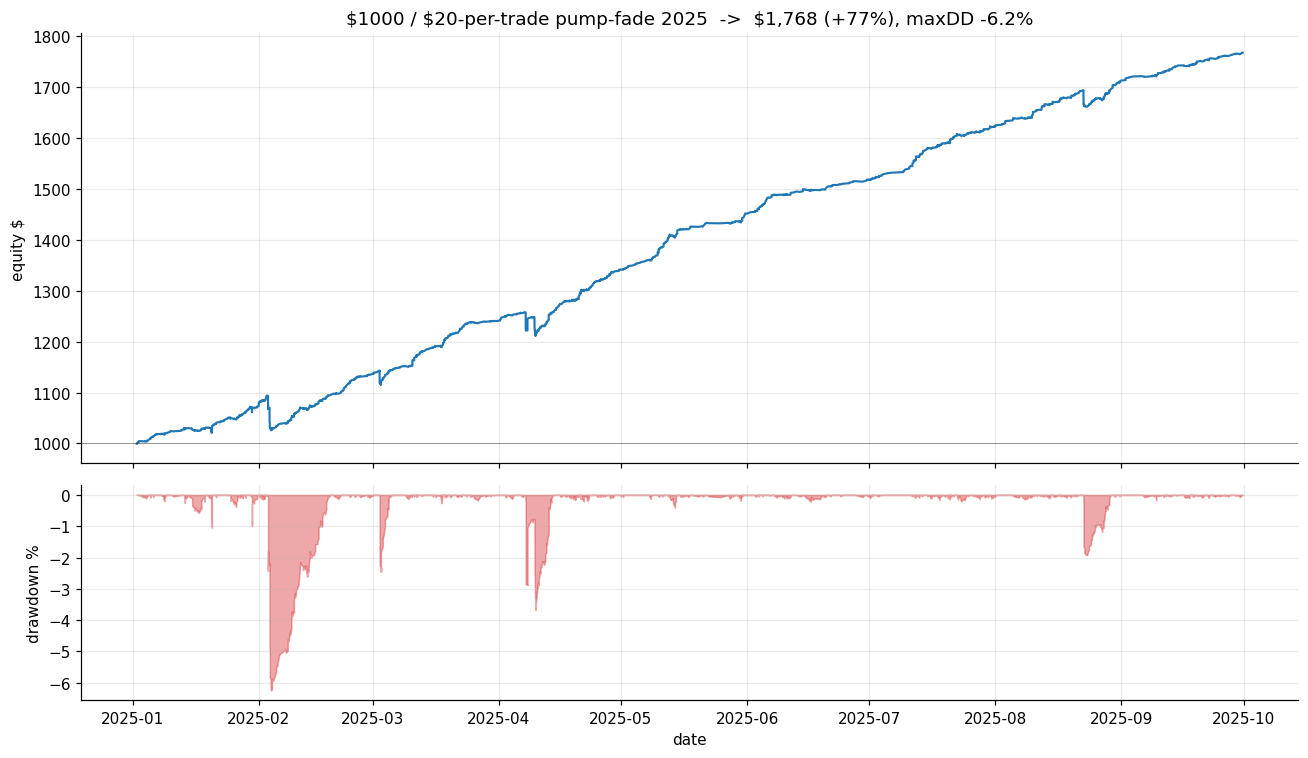

In [4]:
eq = pd.Series(curve_eq, index=pd.to_datetime(curve_t)).sort_index()
peak = eq.cummax()
dd = (eq / peak - 1) * 100
maxdd = dd.min()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                               gridspec_kw={'height_ratios': [2, 1]})
ax1.plot(eq.index, eq.values, lw=1.4)
ax1.axhline(CAPITAL, color='k', lw=0.6, alpha=0.4)
ax1.set_ylabel('equity $'); ax1.set_title(
    f'$1000 / $20-per-trade pump-fade 2025  ->  ${equity:,.0f} '
    f'({(equity/CAPITAL-1)*100:+.0f}%), maxDD {maxdd:.1f}%')
ax2.fill_between(dd.index, dd.values, 0, color='tab:red', alpha=0.4)
ax2.set_ylabel('drawdown %'); ax2.set_xlabel('date')
show('08_portfolio_equity')

months = 9
ann = (equity / CAPITAL) ** (12 / months) - 1
print(f'max drawdown: {maxdd:.1f}%')
print(f'annualized (geometric, x{12/months:.2f}): {ann*100:+.0f}%')

## Sensitivity: does trade size matter?

Bigger $/trade = fewer concurrent slots = more skips in clusters = lower return
but possibly milder cluster drawdowns. Sweep it.

In [5]:
def run_portfolio(size):
    eqx = CAPITAL; comm = 0.0; op = []; tk = sk = 0
    ct, ce = [], []
    for k in order:
        now = entry[k]
        while op and op[0][0] <= now:
            _, pd_ = heapq.heappop(op); eqx += pd_; comm -= size; ct.append(now); ce.append(eqx)
        if eqx - comm >= size:
            heapq.heappush(op, (exit_t[k], size*(pnl[k]-COST))); comm += size; tk += 1
        else:
            sk += 1
    while op:
        t, pd_ = heapq.heappop(op); eqx += pd_; comm -= size; ct.append(t); ce.append(eqx)
    s = pd.Series(ce, index=pd.to_datetime(ct)).sort_index()
    mdd = (s/s.cummax()-1).min()*100
    return eqx, tk, sk, mdd

print(f"{'$/trade':>8}{'%cap':>6}{'taken':>7}{'skip%':>7}{'final$':>10}{'ret%':>8}{'maxDD%':>8}")
for size in [10, 20, 40, 50, 100]:
    fe, tk, sk, mdd = run_portfolio(float(size))
    print(f"{size:>8}{size/CAPITAL*100:>5.0f}%{tk:>7}{sk/(tk+sk)*100:>6.0f}%"
          f"{fe:>10,.0f}{(fe/CAPITAL-1)*100:>+7.0f}%{mdd:>7.1f}%")

 $/trade  %cap  taken  skip%    final$    ret%  maxDD%
      10    1%   2136     2%     1,345    +35%   -6.4%
      20    2%   2017     7%     1,768    +77%   -6.2%
      40    4%   1886    13%     2,651   +165%   -6.5%
      50    5%   1848    15%     3,094   +209%   -6.6%
     100   10%   1758    19%     5,289   +429%   -6.0%
